In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from nltk.corpus import opinion_lexicon
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import numpy as np

## 1. Import data.

Make sure all the files are in the working directory.

In [2]:
csv_paths = list(Path("../Dataset/data_old_approach/processed_data/").glob("*.csv"))

print("CSV files found:")
for p in csv_paths:
    print(p.name)

CSV files found:
old_preprocessed_lexicon.csv
old_preprocessed_transformer.csv


In [3]:
file_path = Path("../Dataset/data_old_approach/processed_data/old_preprocessed_lexicon.csv")

lexicon_df = pd.read_csv(file_path)

lexicon_df.head()

,tokens,bank,platform,rating,date,raw_text
0,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...
1,"['america', 'application', 'benefit', 'america...",Bank Of America,iOS,5,2025-12-28 11:48:52-07:00,Bank Of America Application Benefit Bank Of Am...
2,"['easy', 'use', 'year', 'old', 'woman', 'like'...",Bank Of America,iOS,5,2025-12-28 10:27:09-07:00,App The app is easy to use for a 63-year-old w...
3,"['white', 'screen', 'use', 'face', 'id', 'log'...",Bank Of America,iOS,1,2025-12-27 20:53:27-07:00,"White screen If you use Face ID, after a while..."
4,"['inbox', 'alert', 'error', 'week', 've', 'una...",Bank Of America,iOS,1,2025-12-27 16:51:26-07:00,Inbox Alert Error For over a week I’ve been un...


## 2. Data Overview

In [4]:
lexicon_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4517 entries, 0 to 4516
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   tokens    4517 non-null   object
 1   bank      4517 non-null   object
 2   platform  4517 non-null   object
 3   rating    4517 non-null   int64 
 4   date      2130 non-null   object
 5   raw_text  4517 non-null   object
dtypes: int64(1), object(5)
memory usage: 211.9+ KB


In [5]:
lexicon_df.head()

,tokens,bank,platform,rating,date,raw_text
0,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...
1,"['america', 'application', 'benefit', 'america...",Bank Of America,iOS,5,2025-12-28 11:48:52-07:00,Bank Of America Application Benefit Bank Of Am...
2,"['easy', 'use', 'year', 'old', 'woman', 'like'...",Bank Of America,iOS,5,2025-12-28 10:27:09-07:00,App The app is easy to use for a 63-year-old w...
3,"['white', 'screen', 'use', 'face', 'id', 'log'...",Bank Of America,iOS,1,2025-12-27 20:53:27-07:00,"White screen If you use Face ID, after a while..."
4,"['inbox', 'alert', 'error', 'week', 've', 'una...",Bank Of America,iOS,1,2025-12-27 16:51:26-07:00,Inbox Alert Error For over a week I’ve been un...


In [6]:
# create a custom stopword list
custom_words = pd.DataFrame({
    "word": ["app", "bank", "banking", "mobile", "iphone", "apple", "android", "phone"],
    "lexicon": "custom"
})

default_stop_words = pd.DataFrame({
    "word": list(ENGLISH_STOP_WORDS),
    "lexicon": "sklearn"
})

custom_stop_words = pd.concat(
    [custom_words, default_stop_words],
    ignore_index=True
).drop_duplicates(subset=["word"])


## 3. Unigram Sentiment Analysis

### BING

In [7]:
# download Bing-style opinion lexicon
nltk.download("opinion_lexicon")

# Create Bing-style sentiment dataframe
positive_words = opinion_lexicon.positive()
negative_words = opinion_lexicon.negative()

bing = pd.DataFrame({
    "word": list(positive_words) + list(negative_words),
    "sentiment": ["positive"] * len(positive_words) + ["negative"] * len(negative_words)
})

# Create review-level dataframe and add a review ID before tokenization
# This is needed later for review-level sentiment scores.
df_english = lexicon_df.copy().reset_index(drop=True)
df_english["review_id"] = df_english.index

# Make sure tokenized reviews keep all original columns, including review_id
reviews_before_sw = df_english.copy()

reviews_before_sw["word"] = (
    reviews_before_sw["raw_text"]
    .fillna("")
    .str.lower()
    .str.findall(r"\b[a-z]+\b")
)

reviews_before_sw = reviews_before_sw.explode("word")
reviews_before_sw = reviews_before_sw.dropna(subset=["word"])

# Remove stopwords
reviews_after_sw = reviews_before_sw[
    ~reviews_before_sw["word"].isin(custom_stop_words["word"])
].copy()

# Inner join with Bing-style sentiment lexicon
bing_words = reviews_after_sw.merge(
    bing,
    on="word",
    how="inner"
)

bing_words.head()

[nltk_data] Downloading package opinion_lexicon to
[nltk_data]     C:\Users\zuzia\AppData\Roaming\nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!


,tokens,bank,platform,rating,date,raw_text,review_id,word,sentiment
0,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,horrible,negative
1,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,horrible,negative
2,"['america', 'application', 'benefit', 'america...",Bank Of America,iOS,5,2025-12-28 11:48:52-07:00,Bank Of America Application Benefit Bank Of Am...,1,benefit,positive
3,"['america', 'application', 'benefit', 'america...",Bank Of America,iOS,5,2025-12-28 11:48:52-07:00,Bank Of America Application Benefit Bank Of Am...,1,good,positive
4,"['easy', 'use', 'year', 'old', 'woman', 'like'...",Bank Of America,iOS,5,2025-12-28 10:27:09-07:00,App The app is easy to use for a 63-year-old w...,2,easy,positive


In [8]:
# Check that review_id was kept in the word-level dataframe
print(bing_words.columns.tolist())
bing_words[["bank", "platform", "review_id", "word", "sentiment"]].head()

['tokens', 'bank', 'platform', 'rating', 'date', 'raw_text', 'review_id', 'word', 'sentiment']


,bank,platform,review_id,word,sentiment
0,Bank Of America,iOS,0,horrible,negative
1,Bank Of America,iOS,0,horrible,negative
2,Bank Of America,iOS,1,benefit,positive
3,Bank Of America,iOS,1,good,positive
4,Bank Of America,iOS,2,easy,positive


### Review sentiment distribution

In [9]:
# Review-level Bing sentiment distribution
# To compute review-level Bing sentiment, the sentiment score is calculated as:
# positive words - negative words.

bing_review = (
    bing_words
    .groupby(["bank", "platform", "review_id", "sentiment"])
    .size()
    .reset_index(name="n")
)

bing_review = (
    bing_review
    .pivot_table(
        index=["bank", "platform", "review_id"],
        columns="sentiment",
        values="n",
        fill_value=0
    )
    .reset_index()
)

bing_review.columns.name = None

# Make sure both columns exist even if one sentiment is absent in the data
if "positive" not in bing_review.columns:
    bing_review["positive"] = 0

if "negative" not in bing_review.columns:
    bing_review["negative"] = 0

bing_review["sentiment_score"] = (
    bing_review["positive"] - bing_review["negative"]
)

# Join the review-level sentiment score back to the review-level dataset
df_sent = df_english.merge(
    bing_review,
    on=["bank", "platform", "review_id"],
    how="left"
)

# Equivalent of summary(df_sent$sentiment_score) in R
print(df_sent["sentiment_score"].describe())
print("Missing values:", df_sent["sentiment_score"].isna().sum())

df_sent.head()

count    4078.000000
mean        0.841099
std         2.251701
min       -16.000000
25%        -1.000000
50%         1.000000
75%         2.000000
max        13.000000
Name: sentiment_score, dtype: float64
Missing values: 439


,tokens,bank,platform,rating,date,raw_text,review_id,negative,positive,sentiment_score
0,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,2.0,0.0,-2.0
1,"['america', 'application', 'benefit', 'america...",Bank Of America,iOS,5,2025-12-28 11:48:52-07:00,Bank Of America Application Benefit Bank Of Am...,1,0.0,2.0,2.0
2,"['easy', 'use', 'year', 'old', 'woman', 'like'...",Bank Of America,iOS,5,2025-12-28 10:27:09-07:00,App The app is easy to use for a 63-year-old w...,2,0.0,6.0,6.0
3,"['white', 'screen', 'use', 'face', 'id', 'log'...",Bank Of America,iOS,1,2025-12-27 20:53:27-07:00,"White screen If you use Face ID, after a while...",3,1.0,0.0,-1.0
4,"['inbox', 'alert', 'error', 'week', 've', 'una...",Bank Of America,iOS,1,2025-12-27 16:51:26-07:00,Inbox Alert Error For over a week I’ve been un...,4,8.0,0.0,-8.0


In [10]:
bing_words_sentiment_counts = (
    bing_words["sentiment"]
    .value_counts()
    .reset_index()
)

bing_words_sentiment_counts.columns = ["sentiment", "n"]

bing_words_sentiment_counts

,sentiment,n
0,positive,7312
1,negative,3882


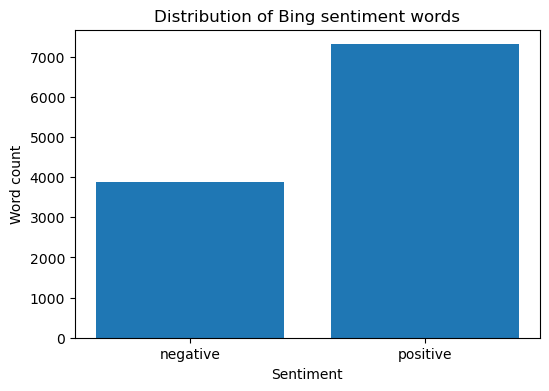

In [11]:
# count sentiment words
sentiment_counts = (
    bing_words
    .groupby("sentiment")
    .size()
    .reset_index(name="n")
)

# plot
plt.figure(figsize=(6, 4))

plt.bar(
    sentiment_counts["sentiment"],
    sentiment_counts["n"]
)

plt.title("Distribution of Bing sentiment words")
plt.xlabel("Sentiment")
plt.ylabel("Word count")

plt.show()

In [12]:
top_bing_words = (
    bing_words
    .groupby(["sentiment", "word"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .groupby("sentiment", group_keys=False)
    .head(10)
)

top_bing_words.head()

,sentiment,word,n
728,positive,easy,973
800,positive,great,639
853,positive,love,409
794,positive,good,361
848,positive,like,361


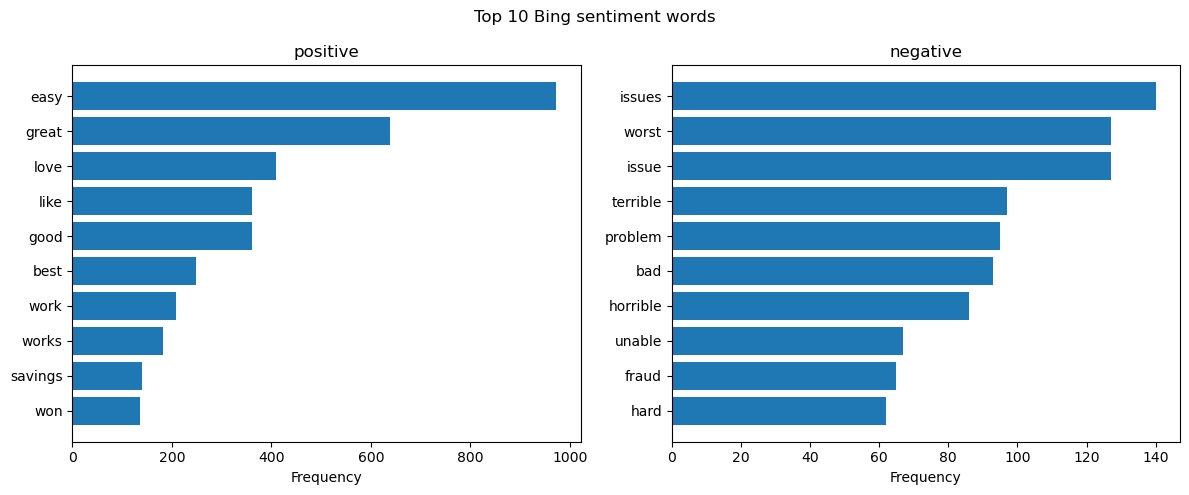

In [13]:
sentiments = top_bing_words["sentiment"].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(sentiments),
    figsize=(12, 5),
    sharex=False
)

if len(sentiments) == 1:
    axes = [axes]

for ax, sentiment in zip(axes, sentiments):
    data = (
        top_bing_words[top_bing_words["sentiment"] == sentiment]
        .sort_values("n")
    )

    ax.barh(data["word"], data["n"])
    ax.set_title(sentiment)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("")

fig.suptitle("Top 10 Bing sentiment words")
plt.tight_layout()
plt.show()

In [14]:
bing_by_bank = (
    bing_words
    .groupby(["bank", "sentiment", "word"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .groupby(["bank", "sentiment"], group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

bing_by_bank.head()

,bank,sentiment,word,n
0,Citi,positive,easy,286
1,Marcus By Goldman Sachs,positive,easy,230
2,Bank Of America,positive,easy,181
3,Marcus By Goldman Sachs,positive,great,166
4,Wells Fargo,positive,easy,146


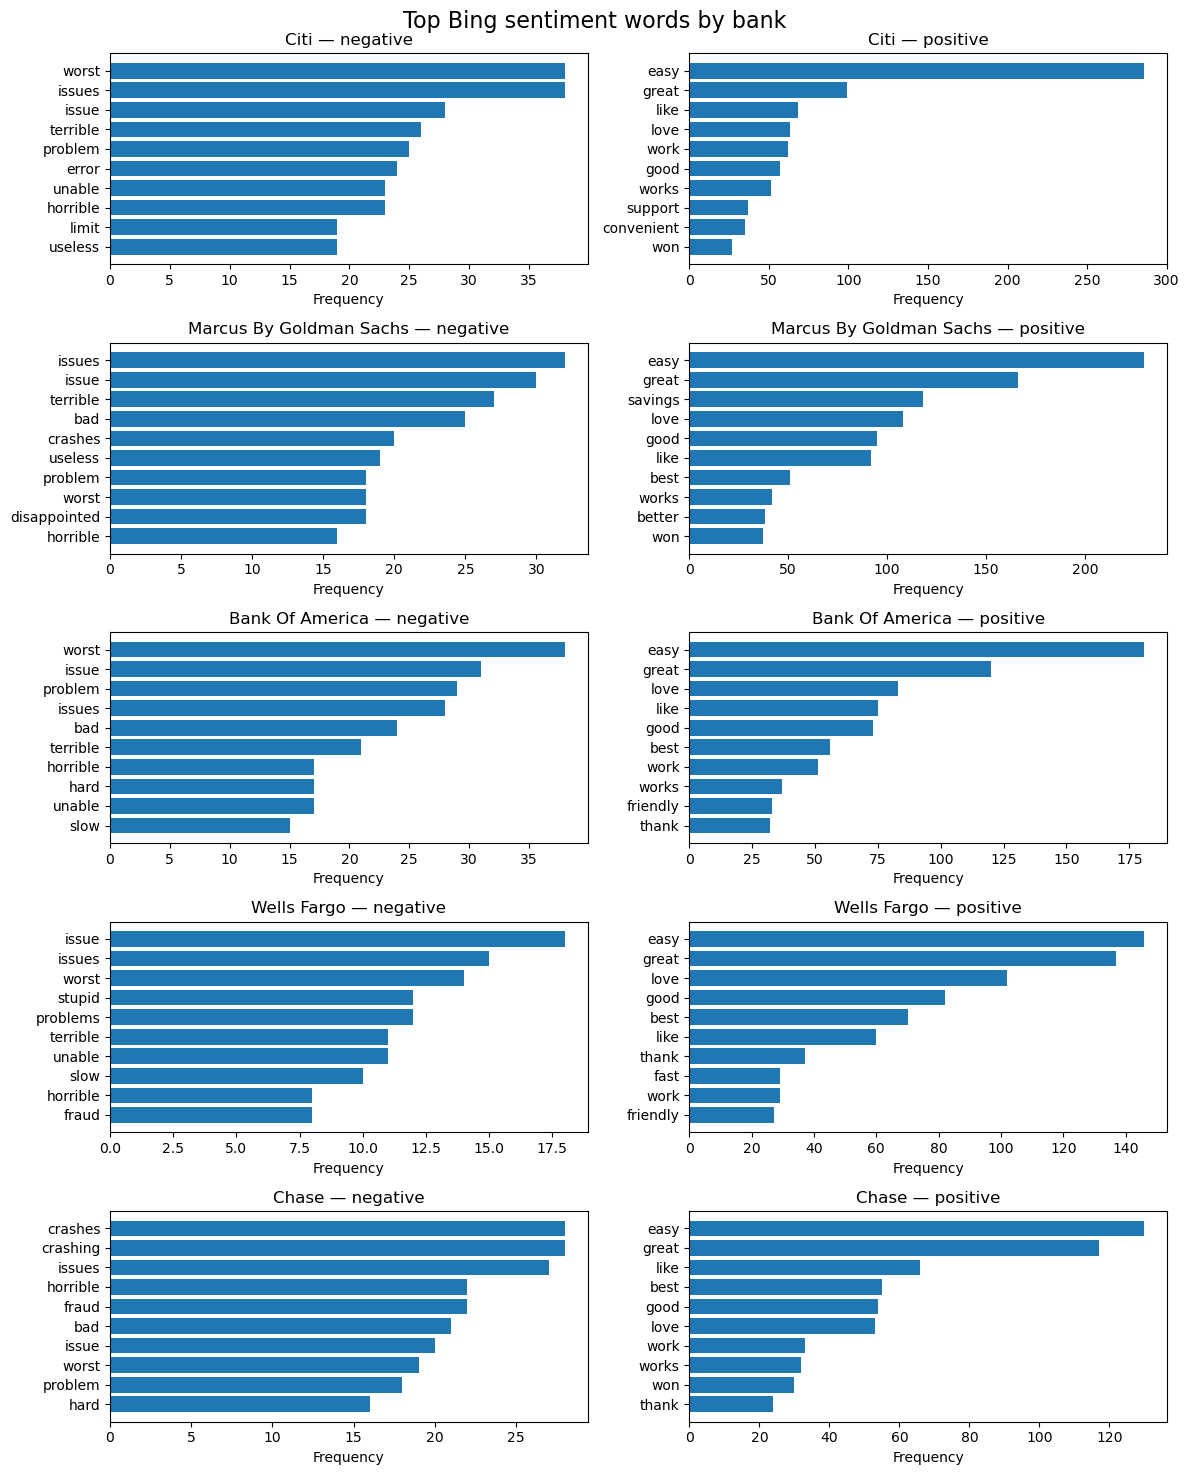

In [15]:
banks = bing_by_bank["bank"].drop_duplicates().tolist()
sentiments = ["negative", "positive"]

fig, axes = plt.subplots(
    nrows=len(banks),
    ncols=len(sentiments),
    figsize=(12, 3 * len(banks)),
    squeeze=False
)

for i, bank in enumerate(banks):
    for j, sentiment in enumerate(sentiments):
        ax = axes[i, j]

        data = (
            bing_by_bank[
                (bing_by_bank["bank"] == bank) &
                (bing_by_bank["sentiment"] == sentiment)
            ]
            .sort_values("n", ascending=True)
        )

        ax.barh(data["word"], data["n"])

        ax.set_title(f"{bank} — {sentiment}")
        ax.set_xlabel("Frequency")
        ax.set_ylabel("")

        if data.empty:
            ax.axis("off")

fig.suptitle("Top Bing sentiment words by bank", fontsize=16)
plt.tight_layout()
plt.show()

In [16]:
# sentiment words by platform
bing_by_platform = (
    bing_words
    .groupby(["platform", "sentiment", "word"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .groupby(["platform", "sentiment"], group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

bing_by_platform.head()

,platform,sentiment,word,n
0,Android,positive,easy,670
1,Android,positive,great,350
2,iOS,positive,easy,303
3,iOS,positive,great,289
4,iOS,positive,like,219


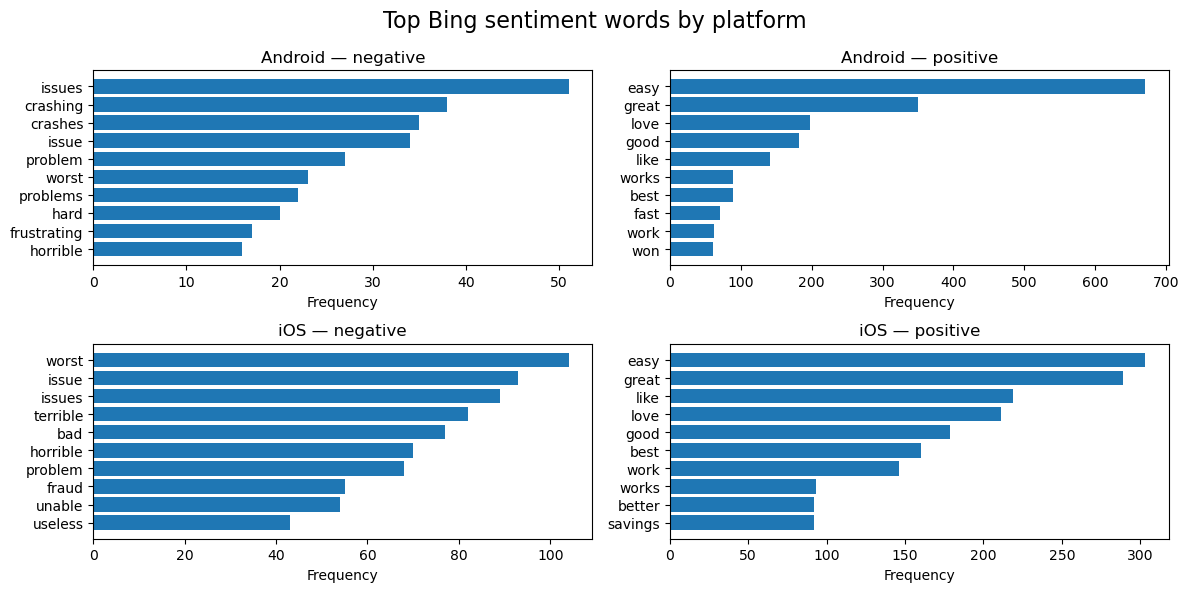

In [17]:
platforms = bing_by_platform["platform"].drop_duplicates().tolist()
sentiments = ["negative", "positive"]

fig, axes = plt.subplots(
    nrows=len(platforms),
    ncols=len(sentiments),
    figsize=(12, 3 * len(platforms)),
    squeeze=False
)

for i, platform in enumerate(platforms):
    for j, sentiment in enumerate(sentiments):
        ax = axes[i, j]

        data = (
            bing_by_platform[
                (bing_by_platform["platform"] == platform) &
                (bing_by_platform["sentiment"] == sentiment)
            ]
            .sort_values("n", ascending=True)
        )

        ax.barh(data["word"], data["n"])

        ax.set_title(f"{platform} — {sentiment}")
        ax.set_xlabel("Frequency")
        ax.set_ylabel("")

        if data.empty:
            ax.axis("off")

fig.suptitle("Top Bing sentiment words by platform", fontsize=16)
plt.tight_layout()
plt.show()

In [18]:
bing_sentiment_pct = (
    bing_words
    .groupby(["bank", "platform", "sentiment"])
    .size()
    .reset_index(name="n")
)

bing_sentiment_pct["pct"] = (
    bing_sentiment_pct["n"] /
    bing_sentiment_pct.groupby(["bank", "platform"])["n"].transform("sum")
)

bing_sentiment_pct.head()

,bank,platform,sentiment,n,pct
0,Bank Of America,Android,negative,163,0.183559
1,Bank Of America,Android,positive,725,0.816441
2,Bank Of America,iOS,negative,621,0.458303
3,Bank Of America,iOS,positive,734,0.541697
4,Chase,Android,negative,280,0.363636


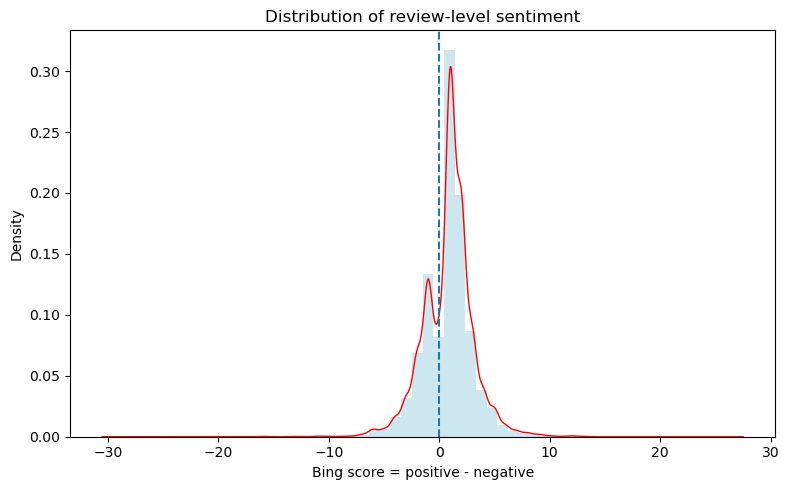

In [19]:
# Keep only finite sentiment scores
df_sent_plot = df_sent[np.isfinite(df_sent["sentiment_score"])].copy()

# Plot histogram + density curve
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df_sent_plot["sentiment_score"],
    bins=30,
    density=True,
    color="lightblue",
    alpha=0.6
)

df_sent_plot["sentiment_score"].plot(
    kind="density",
    ax=ax,
    color="red",
    linewidth=1
)

ax.axvline(0, linestyle="--")

ax.set_title("Distribution of review-level sentiment")
ax.set_xlabel("Bing score = positive - negative")
ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

### Sentiment score and star ratings

C:\Users\zuzia\AppData\Local\Temp\ipykernel_18608\2471032148.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


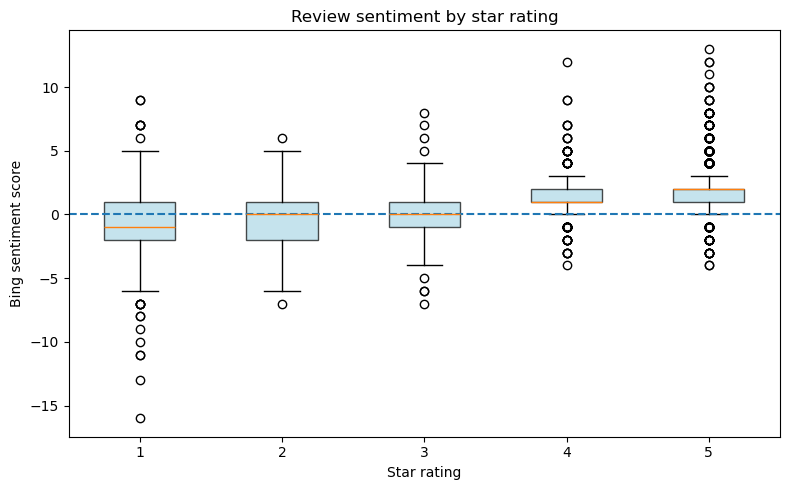

In [20]:
# Sentiment score and star ratings
# This plot shows whether the Bing sentiment score becomes more positive as star ratings increase.

rating_col = "rating"

if rating_col not in df_sent_plot.columns:
    raise KeyError(
        f"Column '{rating_col}' was not found. Available columns are: {df_sent_plot.columns.tolist()}"
    )

rating_plot = df_sent_plot.copy()
rating_plot[rating_col] = pd.to_numeric(rating_plot[rating_col], errors="coerce")
rating_plot["sentiment_score"] = pd.to_numeric(rating_plot["sentiment_score"], errors="coerce")

rating_plot = rating_plot.dropna(subset=[rating_col, "sentiment_score"])
rating_plot = rating_plot[np.isfinite(rating_plot["sentiment_score"])]

ratings = sorted(rating_plot[rating_col].unique())
box_data = [
    rating_plot.loc[rating_plot[rating_col] == rating, "sentiment_score"]
    for rating in ratings
]

rating_labels = [
    str(int(rating)) if float(rating).is_integer() else str(rating)
    for rating in ratings
]

fig, ax = plt.subplots(figsize=(8, 5))

box = ax.boxplot(
    box_data,
    labels=rating_labels,
    patch_artist=True
)

for patch in box["boxes"]:
    patch.set_facecolor("lightblue")
    patch.set_alpha(0.7)

ax.axhline(0, linestyle="--")

ax.set_title("Review sentiment by star rating")
ax.set_xlabel("Star rating")
ax.set_ylabel("Bing sentiment score")

plt.tight_layout()
plt.show()

### AFINN

In [21]:
# Load AFINN sentiment lexicon
# AFINN assigns each sentiment word a numeric score, usually from -5 to +5.
# If you already have AFINN-111.txt locally, place it in the notebook folder.

from pathlib import Path

local_afinn_path = Path("AFINN-111.txt")
afinn_url = "https://raw.githubusercontent.com/fnielsen/afinn/master/afinn/data/AFINN-111.txt"

if local_afinn_path.exists():
    afinn = pd.read_csv(
        local_afinn_path,
        sep="\t",
        names=["word", "value"]
    )
else:
    afinn = pd.read_csv(
        afinn_url,
        sep="\t",
        names=["word", "value"]
    )

afinn["word"] = afinn["word"].str.lower()
afinn["value"] = pd.to_numeric(afinn["value"], errors="coerce")

afinn.head()

,word,value
0,abandon,-2
1,abandoned,-2
2,abandons,-2
3,abducted,-2
4,abduction,-2


In [22]:
# Join AFINN scores to the tokenized review words
afinn_words = reviews_after_sw.merge(
    afinn,
    on="word",
    how="inner"
)

print("AFINN words:", len(afinn_words))
print("Bing words:", len(bing_words))

afinn_words.head()

AFINN words: 9659
Bing words: 11194


,tokens,bank,platform,rating,date,raw_text,review_id,word,value
0,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,horrible,-3
1,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,horrible,-3
2,"['america', 'application', 'benefit', 'america...",Bank Of America,iOS,5,2025-12-28 11:48:52-07:00,Bank Of America Application Benefit Bank Of Am...,1,benefit,2
3,"['america', 'application', 'benefit', 'america...",Bank Of America,iOS,5,2025-12-28 11:48:52-07:00,Bank Of America Application Benefit Bank Of Am...,1,good,3
4,"['easy', 'use', 'year', 'old', 'woman', 'like'...",Bank Of America,iOS,5,2025-12-28 10:27:09-07:00,App The app is easy to use for a 63-year-old w...,2,easy,1


In [23]:
# Most frequent AFINN-scored words
top_afinn_words = (
    afinn_words
    .groupby(["word", "value"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

top_afinn_words

,word,value,n
0,easy,1,973
1,great,3,639
2,love,3,409
3,like,2,361
4,good,3,361
5,best,3,249
6,pay,-1,200
7,help,2,163
8,want,1,137
9,won,3,136


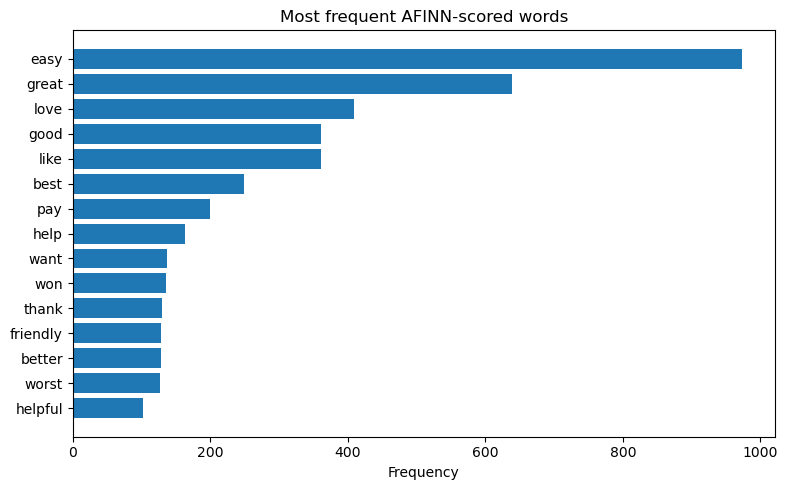

In [24]:
# Plot most frequent AFINN-scored words
plot_data = top_afinn_words.sort_values("n", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(plot_data["word"], plot_data["n"])

ax.set_title("Most frequent AFINN-scored words")
ax.set_xlabel("Frequency")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### Review-level AFINN sentiment

In [25]:
# Create the total AFINN score for each review and the mean AFINN score per review
afinn_review = (
    afinn_words
    .groupby(["bank", "platform", "review_id"])
    .agg(
        afinn_sum=("value", "sum"),
        afinn_mean=("value", "mean"),
        n_afinn=("value", "size")
    )
    .reset_index()
)

# Join review-level AFINN scores back to the review-level dataset
df_afinn = df_english.copy()
df_afinn["rating"] = pd.to_numeric(df_afinn["rating"], errors="coerce")

df_afinn = df_afinn.merge(
    afinn_review,
    on=["bank", "platform", "review_id"],
    how="left"
)

df_afinn.head()

,tokens,bank,platform,rating,date,raw_text,review_id,afinn_sum,afinn_mean,n_afinn
0,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,-6.0,-3.000000,2.0
1,"['america', 'application', 'benefit', 'america...",Bank Of America,iOS,5,2025-12-28 11:48:52-07:00,Bank Of America Application Benefit Bank Of Am...,1,5.0,2.500000,2.0
2,"['easy', 'use', 'year', 'old', 'woman', 'like'...",Bank Of America,iOS,5,2025-12-28 10:27:09-07:00,App The app is easy to use for a 63-year-old w...,2,9.0,1.800000,5.0
3,"['white', 'screen', 'use', 'face', 'id', 'log'...",Bank Of America,iOS,1,2025-12-27 20:53:27-07:00,"White screen If you use Face ID, after a while...",3,-3.0,-3.000000,1.0
4,"['inbox', 'alert', 'error', 'week', 've', 'una...",Bank Of America,iOS,1,2025-12-27 16:51:26-07:00,Inbox Alert Error For over a week I’ve been un...,4,-7.0,-1.166667,6.0


In [26]:
# How many reviews received an AFINN score?
afinn_scoring_summary = pd.DataFrame({
    "total_reviews": [len(df_afinn)],
    "scored_reviews": [df_afinn["afinn_sum"].notna().sum()],
    "pct_scored": [100 * df_afinn["afinn_sum"].notna().mean()]
})

afinn_scoring_summary

,total_reviews,scored_reviews,pct_scored
0,4517,3832,84.835068


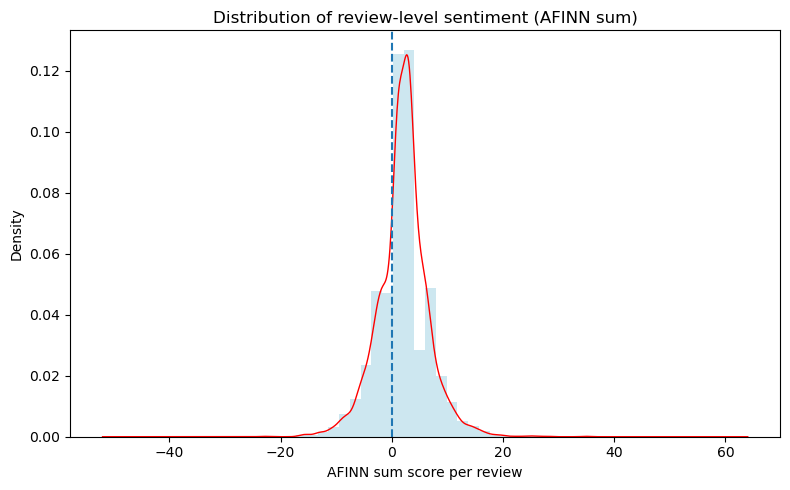

In [27]:
# Distribution of review-level AFINN sentiment
df_afinn_plot = df_afinn[np.isfinite(df_afinn["afinn_sum"])].copy()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df_afinn_plot["afinn_sum"],
    bins=30,
    density=True,
    color="lightblue",
    alpha=0.6
)

df_afinn_plot["afinn_sum"].plot(
    kind="density",
    ax=ax,
    color="red",
    linewidth=1
)

ax.axvline(0, linestyle="--")

ax.set_title("Distribution of review-level sentiment (AFINN sum)")
ax.set_xlabel("AFINN sum score per review")
ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

### AFINN sentiment by bank and platform

In [28]:
# How tone varies by bank and platform
afinn_bank_platform = (
    df_afinn
    .groupby(["bank", "platform"])
    .agg(
        mean_sum=("afinn_sum", "mean"),
        mean_mean=("afinn_mean", "mean"),
        n_reviews=("review_id", "size"),
        n_scored=("afinn_sum", lambda x: x.notna().sum())
    )
    .reset_index()
)

afinn_bank_platform

,bank,platform,mean_sum,mean_mean,n_reviews,n_scored
0,Bank Of America,Android,2.762626,1.585835,458,396
1,Bank Of America,iOS,1.231383,0.524831,446,376
2,Chase,Android,1.942197,1.310460,474,346
3,Chase,iOS,1.306233,0.603432,420,369
4,Citi,Android,2.612676,1.519799,473,426
5,Citi,iOS,-0.566234,-0.216948,456,385
6,Marcus By Goldman Sachs,Android,2.452055,1.254515,526,438
7,Marcus By Goldman Sachs,iOS,3.026190,0.937953,481,420
8,Wells Fargo,Android,2.179894,1.426184,456,378
9,Wells Fargo,iOS,3.469799,1.443535,327,298


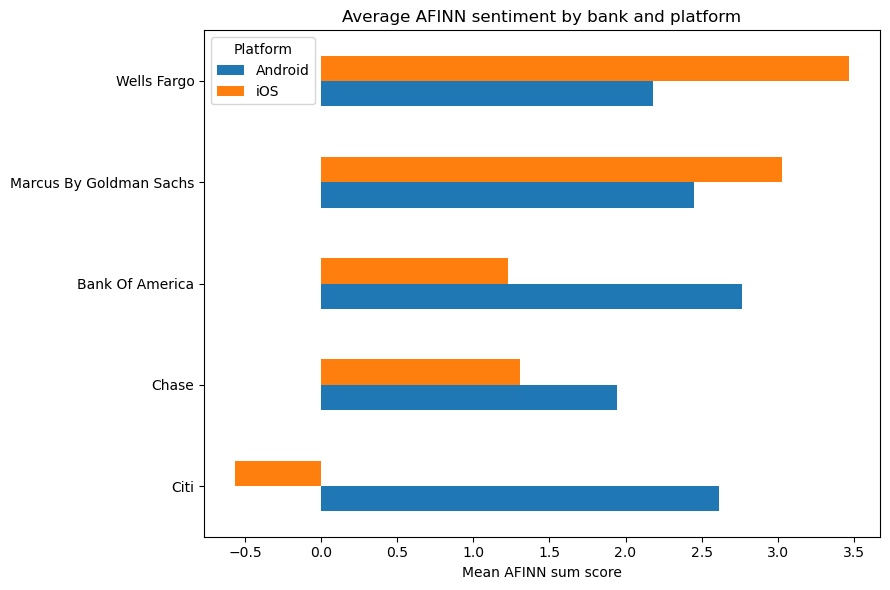

In [29]:
# Plot average AFINN sentiment by bank and platform
pivot_plot = afinn_bank_platform.pivot(
    index="bank",
    columns="platform",
    values="mean_sum"
)

# Order banks by the average AFINN score across platforms
bank_order = pivot_plot.mean(axis=1).sort_values().index
pivot_plot = pivot_plot.loc[bank_order]

fig, ax = plt.subplots(figsize=(9, 6))

pivot_plot.plot(
    kind="barh",
    ax=ax
)

ax.set_title("Average AFINN sentiment by bank and platform")
ax.set_xlabel("Mean AFINN sum score")
ax.set_ylabel("")
ax.legend(title="Platform")

plt.tight_layout()
plt.show()

### Top AFINN words by sentiment score

In [30]:
# Top AFINN sentiment words by score
top_afinn_by_score = (
    afinn_words
    .groupby(["value", "word"])
    .size()
    .reset_index(name="n")
    .sort_values(["value", "n"], ascending=[True, False])
    .groupby("value", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

top_afinn_by_score

,value,word,n
0,-4,fraud,65
1,-4,fraudulent,9
2,-4,hell,3
3,-4,damn,2
4,-4,wtf,2
...,...,...,...
74,4,wins,2
75,4,brilliant,1
76,5,outstanding,19
77,5,superb,4


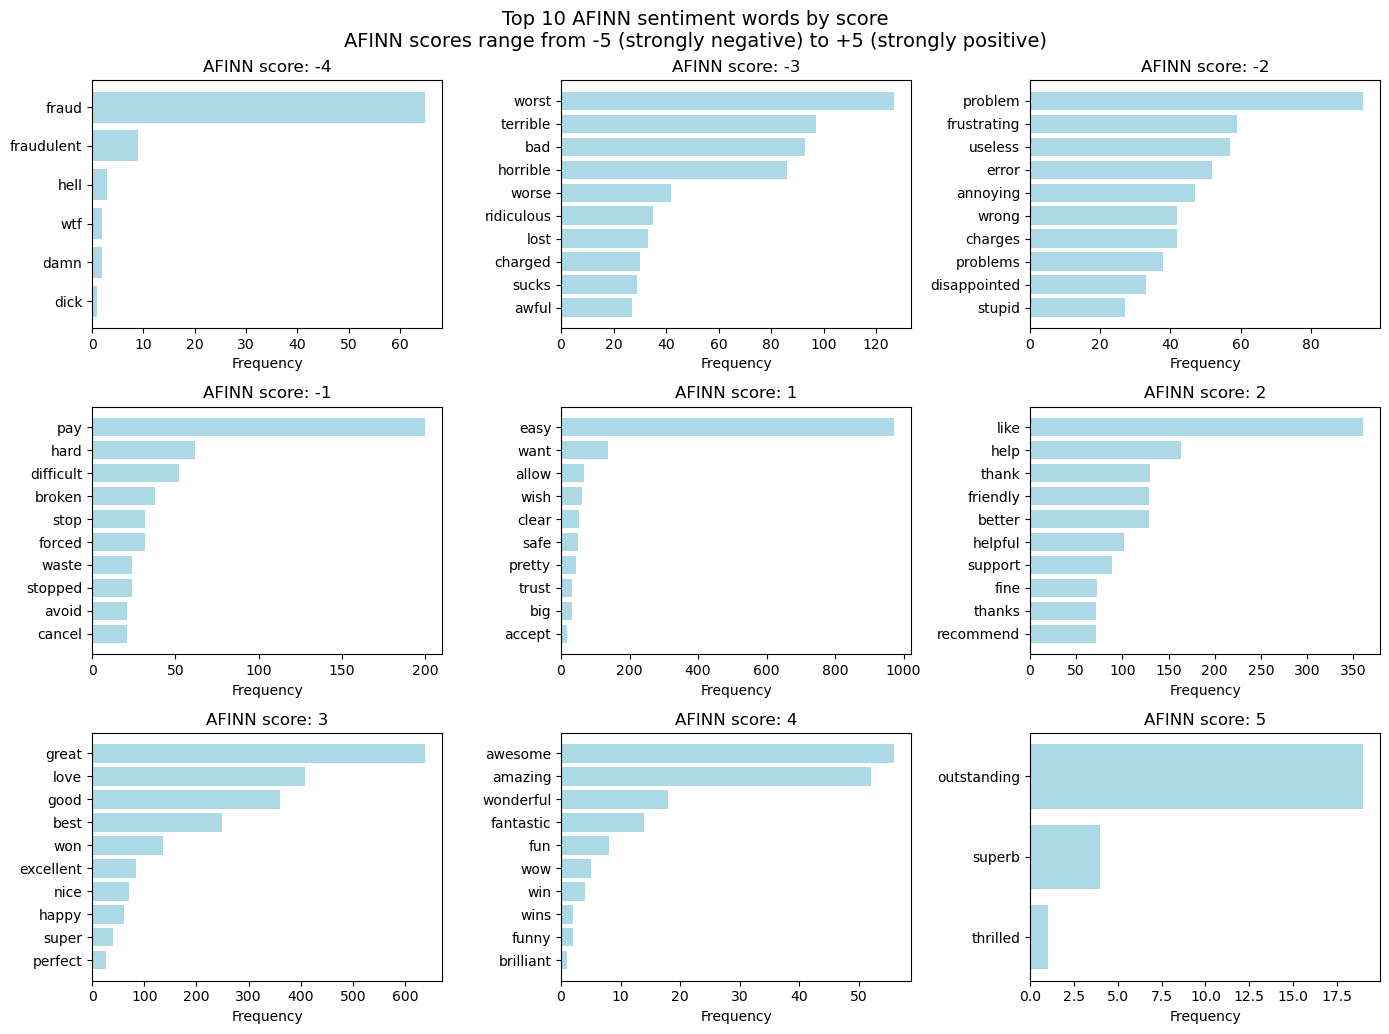

In [31]:
# Plot top AFINN words by score
import math

values = sorted(top_afinn_by_score["value"].dropna().unique())
ncols = 3
nrows = math.ceil(len(values) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 3.5 * nrows),
    squeeze=False
)

axes_flat = axes.flatten()

for ax, value in zip(axes_flat, values):
    data = (
        top_afinn_by_score[top_afinn_by_score["value"] == value]
        .sort_values("n", ascending=True)
    )
    
    ax.barh(data["word"], data["n"], color="lightblue")
    ax.set_title(f"AFINN score: {int(value)}")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("")

for ax in axes_flat[len(values):]:
    ax.axis("off")

fig.suptitle(
    "Top 10 AFINN sentiment words by score\nAFINN scores range from -5 (strongly negative) to +5 (strongly positive)",
    fontsize=14
)

plt.tight_layout()
plt.show()

### AFINN sentiment and star ratings

C:\Users\zuzia\AppData\Local\Temp\ipykernel_18608\2826671166.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


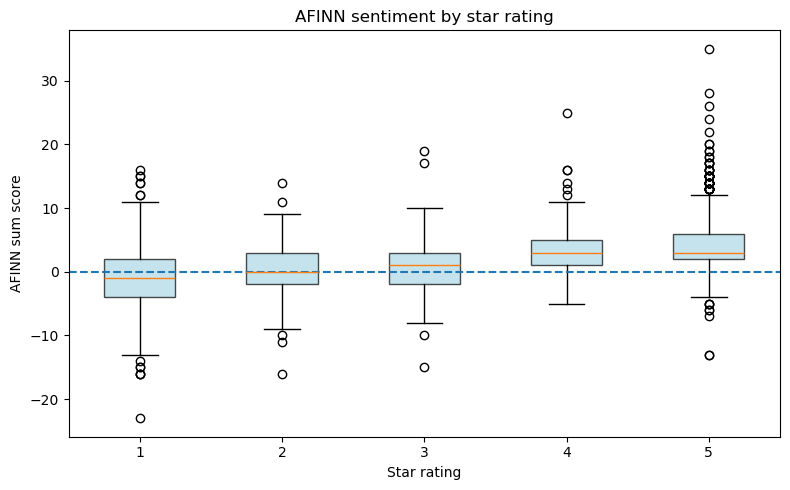

In [32]:
# AFINN sentiment by star rating
df_afinn_rating_plot = df_afinn.copy()
df_afinn_rating_plot["rating"] = pd.to_numeric(df_afinn_rating_plot["rating"], errors="coerce")
df_afinn_rating_plot["afinn_sum"] = pd.to_numeric(df_afinn_rating_plot["afinn_sum"], errors="coerce")

df_afinn_rating_plot = df_afinn_rating_plot.dropna(subset=["rating", "afinn_sum"])
df_afinn_rating_plot = df_afinn_rating_plot[np.isfinite(df_afinn_rating_plot["afinn_sum"])]

ratings = sorted(df_afinn_rating_plot["rating"].unique())
box_data = [
    df_afinn_rating_plot.loc[df_afinn_rating_plot["rating"] == rating, "afinn_sum"]
    for rating in ratings
]

rating_labels = [
    str(int(rating)) if float(rating).is_integer() else str(rating)
    for rating in ratings
]

fig, ax = plt.subplots(figsize=(8, 5))

box = ax.boxplot(
    box_data,
    labels=rating_labels,
    patch_artist=True
)

for patch in box["boxes"]:
    patch.set_facecolor("lightblue")
    patch.set_alpha(0.7)

ax.axhline(0, linestyle="--")

ax.set_title("AFINN sentiment by star rating")
ax.set_xlabel("Star rating")
ax.set_ylabel("AFINN sum score")

plt.tight_layout()
plt.show()

In [33]:
# Pearson correlation between star rating and AFINN sum score
from scipy.stats import pearsonr

cor_data = df_afinn_rating_plot[["rating", "afinn_sum"]].dropna()

if len(cor_data) >= 3:
    r, p_value = pearsonr(cor_data["rating"], cor_data["afinn_sum"])
    n = len(cor_data)
    
    # Approximate 95% confidence interval using Fisher z-transformation
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_crit = 1.96
    ci_low, ci_high = np.tanh([z - z_crit * se, z + z_crit * se])
    
    print("Pearson correlation test")
    print(f"n = {n}")
    print(f"correlation = {r:.4f}")
    print(f"p-value = {p_value:.4g}")
    print(f"95% CI = [{ci_low:.4f}, {ci_high:.4f}]")
else:
    print("Not enough complete observations for correlation test.")

Pearson correlation test
n = 3832
correlation = 0.5282
p-value = 1.975e-274
95% CI = [0.5050, 0.5507]


# 4. Transformer Based Sentiment Analysis